## KNN

In [1]:
##Load in Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, average_precision_score, precision_recall_curve
)

In [2]:
## Load in Data
train_df = pd.read_csv('../data/processed/processed_train.csv')
test_df  = pd.read_csv('../data/processed/processed_test.csv')

print('Train shape:', train_df.shape)
print('Test shape: ', test_df.shape)
train_df.head()

Train shape: (103904, 23)
Test shape:  (25976, 23)


,Gender,Customer_Type,Age,Type_of_Travel,Class,Flight_Distance,Inflight_wifi_service,Departure/Arrival_time_convenient,Ease_of_Online_booking,Gate_location,...,Inflight_entertainment,On-board_service,Leg_room_service,Baggage_handling,Checkin_service,Inflight_service,Cleanliness,satisfaction,Total_Delay,Avg_Service_Rating
0,1,0,13,1,1,460,3,4,3,1,...,5,4,3,4,4,5,5,0,43.0,3.857143
1,1,1,25,0,2,235,3,2,3,3,...,1,1,5,3,1,4,1,0,7.0,2.285714
2,0,0,26,0,2,1142,2,2,2,2,...,5,4,3,4,4,4,5,1,0.0,3.714286
3,0,0,25,0,2,562,2,5,5,5,...,2,2,5,3,1,4,2,0,20.0,3.000000
4,1,0,61,0,2,214,3,3,3,3,...,3,3,4,4,3,3,3,1,0.0,3.500000


In [3]:
## target Split
TARGET = 'satisfaction'

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

In [4]:
## Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Best k: 7 (F1 = 0.9139)


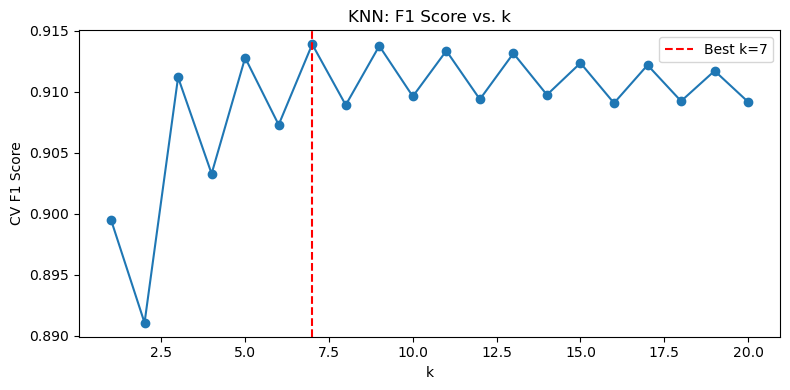

In [ ]:
## Find Optimal K
## Can take a little while to run
k_range = range(1, 21)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(knn, X_train_scaled, y_train, cv=cv, scoring='f1')
    k_scores.append(scores['test_score'].mean())

best_k = k_range[np.argmax(k_scores)]
print(f'Best k: {best_k} (F1 = {max(k_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('CV F1 Score')
plt.title('KNN: F1 Score vs. k')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
## Stratified K-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    KNeighborsClassifier(n_neighbors=best_k),
    X_train_scaled, y_train,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1', 'average_precision'],
    return_train_score=True
)

print(f"CV Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"CV ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"CV F1 Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"CV PR-AUC:    {cv_results['test_average_precision'].mean():.4f} ± {cv_results['test_average_precision'].std():.4f}")

CV Accuracy:  0.9283 ± 0.0019
CV ROC-AUC:   0.9732 ± 0.0014
CV F1 Score:  0.9139 ± 0.0025
CV PR-AUC:    0.9649 ± 0.0020


In [7]:
## Train Final Model
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [8]:
## Evaluate on Test Set
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
print(f'PR-AUC:   {average_precision_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Neutral/Dissatisfied', 'Satisfied']))

Accuracy: 0.9302
ROC-AUC:  0.9749
F1 Score: 0.9175
PR-AUC:   0.9674

                      precision    recall  f1-score   support

Neutral/Dissatisfied       0.91      0.97      0.94     14573
           Satisfied       0.95      0.88      0.92     11403

            accuracy                           0.93     25976
           macro avg       0.93      0.93      0.93     25976
        weighted avg       0.93      0.93      0.93     25976



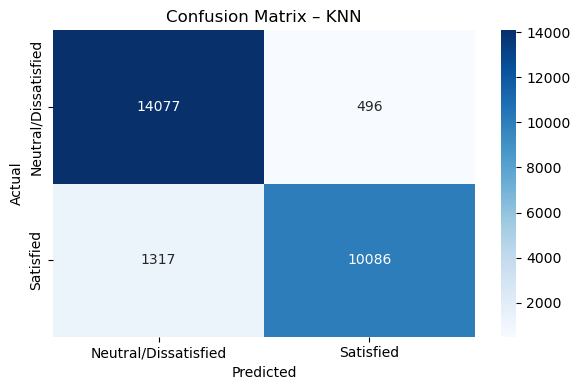

In [9]:
##Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral/Dissatisfied', 'Satisfied'],
            yticklabels=['Neutral/Dissatisfied', 'Satisfied'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix – KNN')
plt.tight_layout()
plt.show()

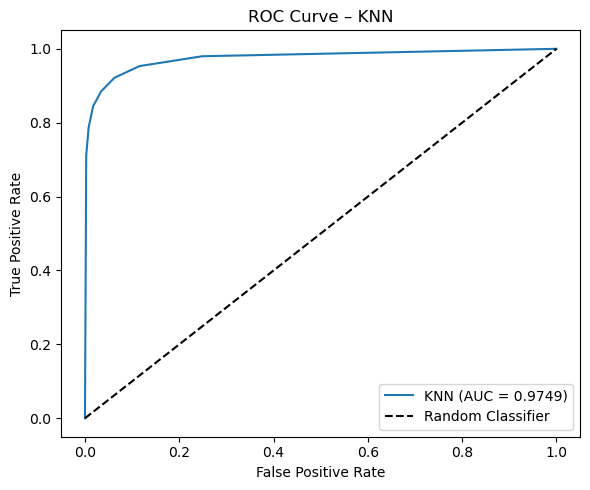

In [10]:
## ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN')
plt.legend()
plt.tight_layout()
plt.show()

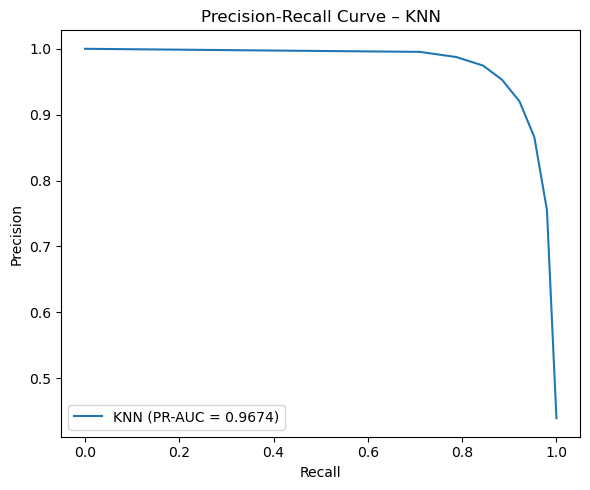

In [11]:
## Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'KNN (PR-AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve – KNN')
plt.legend()
plt.tight_layout()
plt.show()